In [1]:
import numpy as np
import numpy.linalg as lin
import sympy as sym
import scipy.linalg as splin
import IPython.display as nb
import matplotlib.pyplot as plt
from numpy.linalg import matrix_rank as rank
from numpy.linalg import norm
from displayutils import display_matrix, display_vector, display_function
from itertools import takewhile
from functools import reduce 
from fractions import Fraction
from sympy.core.sympify import sympify 
from sympy.parsing.mathematica import parse_mathematica

## Esame di Metodi Numerici 6 Maggio 2024 

## Esercizo 1
- Si consideri il sistema lineare Ax=b, con A matrice e b termine noto memorizzati nel file ``'test_14_09_2023.mat'``.  Risolvere il sistema confrontando almeno due tra i metodi  visti  per utilizzare per risolvere il sistema lineare con tale matrice dei coefficienti. Confrontare i risultati dei vari metodi, e giustificare i loro comportamento utilizzando i risultati teorici visti a lezione.
- 
Per la lettura dei dati procedere nel seguente modo:

``from scipy.io import loadmat``

``import numpy as np``

``dati = loadmat('test_06_05_2024.mat')``

``A=dati["A"] ``

``A=A.astype(float)``

`` b=dati["b"] ``

`` b=b.astype(float)``


                                       [10 punti]
                                         


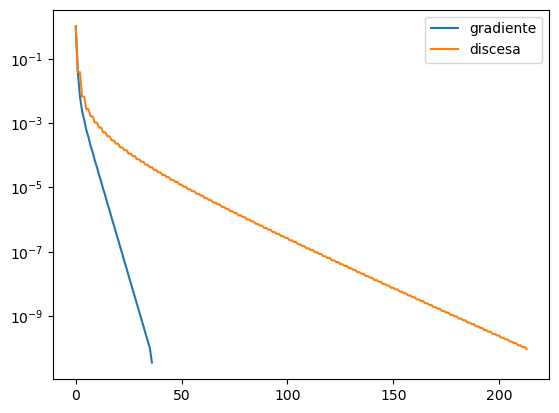

In [2]:
from scipy.io import loadmat


def iterate(func, start):
    while True:
        yield start
        start = func(*start)
    
#A è la matrice di Poisson scalata di due, è una matrice grande sparsa, simmettrice e definita positiva, quindi usiamo il gradiente cogniugato
def steep(A: np, b, alfa, dir, x0=None, itmax: int=1000, toll: float=1e-10):
    err = lambda num, den: norm(num)/norm(den)
    
    if x0 is None:
        x0 = np.zeros_like(b)
        
    def stop_criteria(i, args):
        res, _, _ = args
        return i < itmax and err(res, b) >= toll
    
    def iteration(res, x, p):
        Ap = A @ p
        a = alfa(A, res, p)
        r = res + a*Ap
        return r, x + a*p, dir(r, res, p)
    
    res = A @ x0 - b
    
    iter = iterate(iteration, (res, x0, -res))
    arr = list(dict(takewhile(lambda param: stop_criteria(*param), enumerate(iter))).values()) + \
        [next(iter)] 
    
    x_arr = [x for res, x, p in arr]
    r_arr = [err(res, b) for res, x, p in arr]
    return x_arr[-1], r_arr, x_arr, len(x_arr)

def conjugate_gradient(A, b):
    alfa = lambda A, res, p: res @ res / (A @ p @ p)
    def p(nres, res, p): 
        gamma = nres @ nres / (res @ res)
        return -nres + (gamma * p)
    return steep(A, b, alfa, p)

def discesa(A, b):
    alfa = lambda A, res, p: -res @ p / (A @ p @ p)
    def p(nres, res, p): 
        return -res
    return steep(A, b, alfa, p)


dati = loadmat('test_06_05_2024.mat')
A=dati["A"]
A=A.astype(float)
b=dati["b"]
b=b.astype(float).ravel()
_, err, _, it = conjugate_gradient(A, b)
_, err1, _, it1 = discesa(A, b)
plt.semilogy(range(it), err)
plt.semilogy(range(it1), err1)
plt.legend(['gradiente', 'discesa'])
plt.show()

- Data la matrice 
$$A=\left[
\begin{array}{cccc}
1 & 2 & 3 & 4\\
2 & -4 & 6 & 8\\
-1 & -2 & -3 & -1\\
5 & 7 & 0 & 1
\end{array}
\right ],$$
Richiamare le ipotesi sotto cui esiste la fattorizzazione di Gauss senza pivoting e scrivere un codice per  verificarle.

                                                [2 punti]

In [3]:
A = np.array([[1, 2, 3, 4],[2,-4, 6, 8],[-1, -2,-3, -1],[5, 7, 0, 1]])

def compute(i):
    minore = A[:i,:i]
    display_matrix(minore)
    print(f"DETERMINANTE {lin.det(minore):.3}")
    return lin.det(minore) != 0

def cond_LU(A):
    return all([compute(i) for i in range(1, len(A)+1)])

if cond_LU(A):
    print("DECOMPOSIZIONE FATTIBILE")
else:
    print("I MINORI DI TESTA NON SONO SINGOLARI")

<IPython.core.display.Latex object>

DETERMINANTE 1.0


<IPython.core.display.Latex object>

DETERMINANTE -8.0


<IPython.core.display.Latex object>

DETERMINANTE 0.0


<IPython.core.display.Latex object>

DETERMINANTE -3.6e+02
I MINORI DI TESTA NON SONO SINGOLARI


## Esercizio 2
Scrivere uno script che calcoli il polinomio interpolante un insieme di punti $P_i =(x_i, y_i)$ $i = 0, ..., n $ nella forma di Lagrange, $n=5,10,15,18$

- nodi $x_i$, punti equidistanti in un intervallo $[a, b]$,
- nodi $x_i$, zeri dei polinomi di Chebyshev nell'intervallo $[a, b]$, ossia
$$
x_i = \frac{(a + b)}{2}+\frac{(b-a)}{2} \, \cos \left(
\frac{(2i+1)\pi}{2(n + 1)}
\right), \quad  i =0, ..., n 
$$
 
  e $y_i = f(x_i)$ ottenuti dalla valutazione nei punti $x_i$ della funzione test   $f: \ [a, b] \rightarrow {\mathbb R}$. 
  - $f(x) = 1/(1+25*x^2)$,  $ \quad x \in [-1, 1]$ (funzione di Runge).
  

  
                                          [6] punti

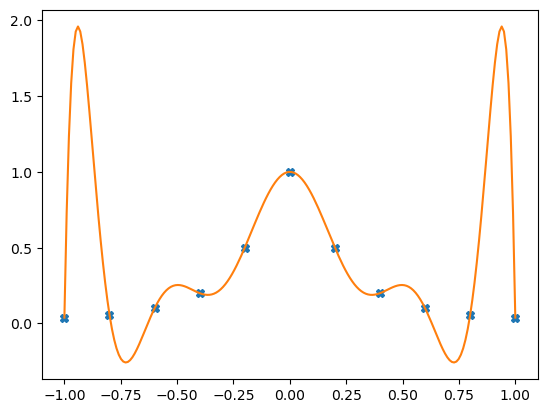

In [38]:
n = np.array([5, 10, 15, 18])

xv = np.linspace(-1, 1, 200)
f = lambda x: 1 / (1 + 25 * x**2)

def plot_order(i):
    x = np.linspace(-1, 1, i+1)
    
    y = f(x)
    plt.plot(x, y, 'X')
    res = iterpL(x, y, xv)    
    plt.plot(xv, res)
    
plot_order(n[1])
plt.show()

- Calcolare l'errore di interpolazione $r(x) =  f(x)-pe(x) $,
tra la funzione test $f(x)$ e il polinomio di interpolazione $pe(x)$ calcolato a partire da nodi equdisitanti.

                                        [1] punto
                                        

Visualizzare il grafico di $f(x)$ e $pe(x)$, ed il grafico di $|r(x)|$ per ogni valore $n=5,10,15,18$ 

                                        [1] punto
                                        

Calcolare l'errore di interpolazione $r(x) =  f(x)-pc(x) $,
tra la funzione test $f(x)$ e il polinomio di interpolazione $p(x)$ calcolato a partire da nodi di Chebichev.

                                      [1] punto
                                            

Visualizzare il grafico di $f(x)$ e $pc(x)$, ed il grafico di $|r(x)|$. 

                                       [1] punto

Cosa si osserva? Cosa accade all'aumentare del grado $n$ di $p(x)$? Scrivere la formula dell'errore che si compie quando al posto della funzione che ha generato i dati si considera il polinomio interpolatore di grado n e commentarla.
                                         
                                         [3 punti]

In [23]:
def print_lagrange(coeff, j, n):
    coeff = np.flip(coeff)
    str = reduce(lambda a, b: a + b, [f'+({Fraction(c)})*x^{i} ' for i, c in enumerate(coeff) if c != 0])
    g = parse_mathematica(str)
    display_function(g, f='L_{ '+f'{j}'+' }^{({ '+f'{n}'+' })}', varsym=sym.symbols(f"x"))

#calcolo del polinoimio di lagrange
def poly_Lagrange(xnodi, j, show):
    zeri = np.zeros_like(xnodi)
    n = xnodi.size
    
    if j == 0:
        zeri = xnodi[1:]
    else:
        zeri = np.append(xnodi[0:j], xnodi[j+1:n])

    
    num = np.poly(zeri)
    den = np.polyval(num, xnodi[j])
    co = num / den
    
    if show:
        print_lagrange(co, j, n)
    return co

def iterpL(x, y, xv, show=False): 
    L = np.array([np.polyval(poly_Lagrange(x, j, show), xv) for j in range(len(x))])
    return L.T @ y



**Domanda AI**

- Descrivere gli elementi caratterizzanti di un MultiLayer Perceptron (MLP).( Com'è fatto un neurone artificiale, a caso servono le funzioni di attivazione, come sono organizzati i neuroni. Varie tipologie di reti MLP)  ed accennare in cosa consiste la fase di forward propagation e la fase di backward propagation. **Punti: 1**

- Ottimizzazione della loss function per il training di una rete neurale per il task di regressione: Metodo di discesa del gradiente, metodo stocastico del gradiente, metodo del gradiente minibatch.  **Punti 1**  
 - Non convessità della loss-function - come non rimanere bloccati in un monimo locale? Metodo del gradiente con momentum. **Punti 2**
- Learning rate scheduling: step decay, decadimento esponenziale, decadimento dipendente dal tempo. **Punti 1**
 - Learning rate adattivo: Adagrad, RMSProp, Adadelta, Adam. **Punti 2**
 
 **Totale:  7**